In [13]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import f_classif

In [2]:
df=pd.read_csv("global_ev_adoption_behavior_2026.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=50000, step=1)
All columns are
0 age
1 annual_income
2 education_level
3 city_type
4 daily_commute_km
5 weekly_travel_distance_km
6 current_vehicle_type
7 vehicle_age_years
8 fuel_expense_per_month
9 charging_station_accessibility
10 nearest_charging_station_km
11 home_charging_available
12 electricity_cost_per_kwh
13 environmental_awareness_score
14 government_incentive_awareness
15 technology_affinity_score
16 range_anxiety_score
17 battery_replacement_concern
18 ev_knowledge_score
19 previous_ev_experience
20 ev_adoption_likelihood
21 monthly_energy_consumption_kwh
22 monthly_charging_cost


In [4]:
df.sample(n=10)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
997,3,67,59,0,40,944,5,33,0,1,1,4
73,2,48,43,0,13,110,5,15,0,1,3,2
163,3,29,26,0,7,34,1,7,0,1,2,3
110,3,61,50,1,30,102,4,9,0,1,3,2
35,3,20,35,1,11,52,4,0,0,0,2,2
545,2,48,31,1,12,52,4,3,0,0,3,4
66,3,28,51,1,22,40,3,10,0,1,6,3
649,3,23,50,0,1,151,4,8,0,1,1,1
811,3,28,22,1,3,23,3,1,0,0,5,1
939,3,16,48,0,25,59,2,13,0,0,2,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   region   1000 non-null   int64
 1   tenure   1000 non-null   int64
 2   age      1000 non-null   int64
 3   marital  1000 non-null   int64
 4   address  1000 non-null   int64
 5   income   1000 non-null   int64
 6   ed       1000 non-null   int64
 7   employ   1000 non-null   int64
 8   retire   1000 non-null   int64
 9   gender   1000 non-null   int64
 10  reside   1000 non-null   int64
 11  custcat  1000 non-null   int64
dtypes: int64(12)
memory usage: 93.9 KB


In [3]:
# Removing null values
df = df.dropna()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 48511 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             48511 non-null  int64  
 1   annual_income                   48511 non-null  float64
 2   education_level                 48511 non-null  object 
 3   city_type                       48511 non-null  object 
 4   daily_commute_km                48511 non-null  float64
 5   weekly_travel_distance_km       48511 non-null  float64
 6   current_vehicle_type            48511 non-null  object 
 7   vehicle_age_years               48511 non-null  float64
 8   fuel_expense_per_month          48511 non-null  float64
 9   charging_station_accessibility  48511 non-null  float64
 10  nearest_charging_station_km     48511 non-null  float64
 11  home_charging_available         48511 non-null  int64  
 12  electricity_cost_per_kwh        48511

<Axes: >

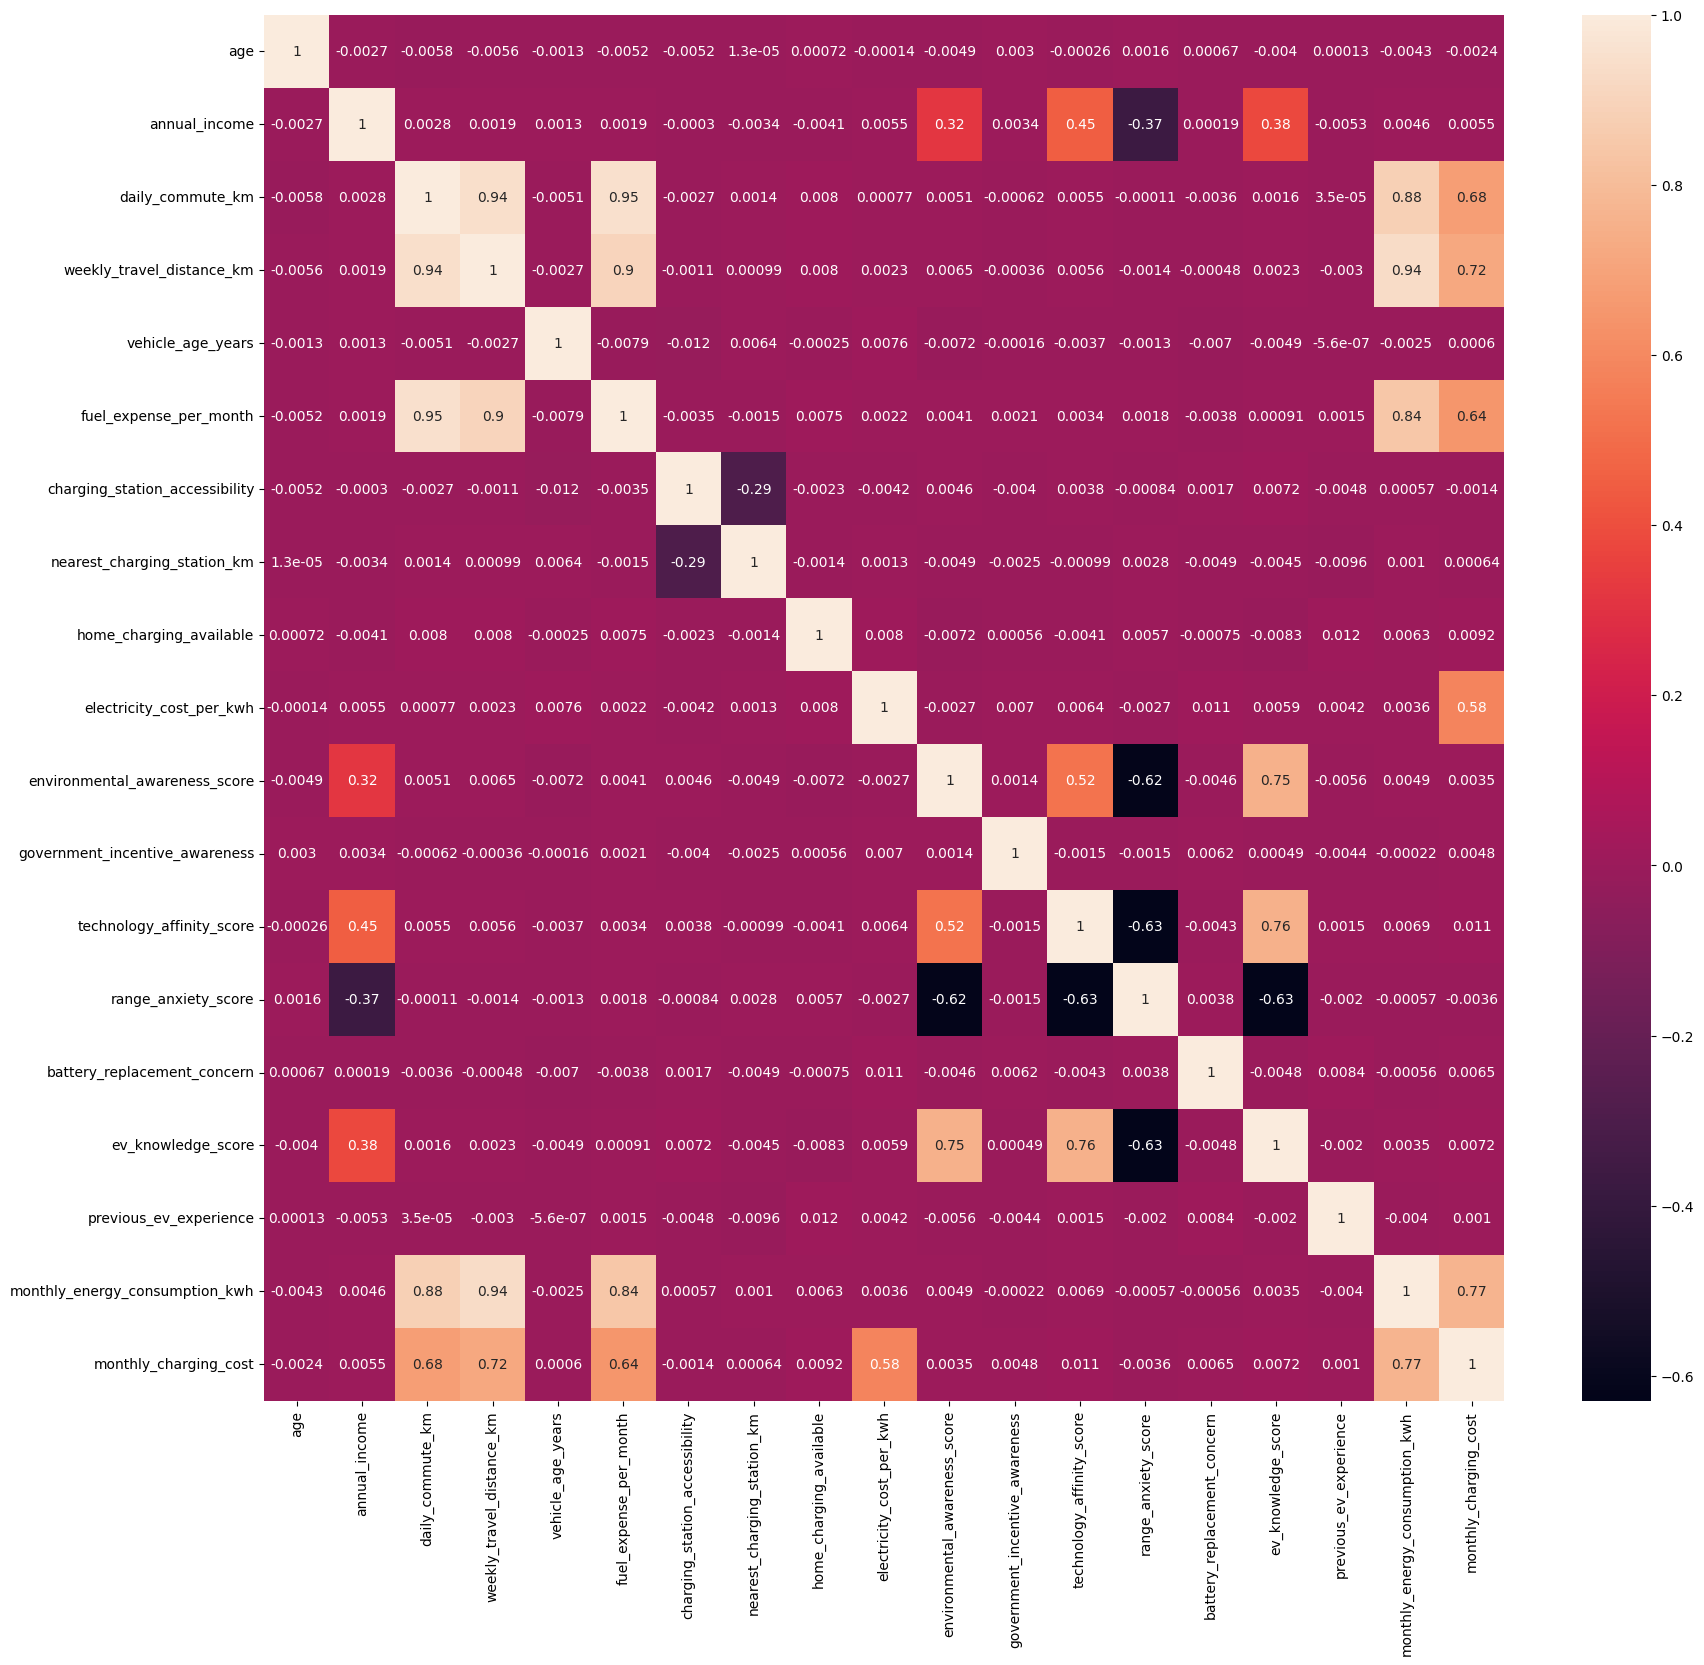

In [5]:
plt.figure(figsize=(20,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [6]:
print('''The Heatmap may not give the best relationship between the features.
As our feature are numerical and the custcat is categorial
So the best test will be ANOVA F-Test''')

The Heatmap may not give the best relationship between the features.
As our feature are numerical and the custcat is categorial
So the best test will be ANOVA F-Test


In [9]:
df.columns

Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost'],
      dtype='object')

In [7]:
df.select_dtypes(include='number').columns

Index(['age', 'annual_income', 'daily_commute_km', 'weekly_travel_distance_km',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'monthly_energy_consumption_kwh',
       'monthly_charging_cost'],
      dtype='object')

In [18]:
# Isolating input and target
X = df[df.select_dtypes(include='number').columns]
y = df["ev_adoption_likelihood"]

In [19]:
fscores, pvalues = f_classif(X, y)

anovadf = pd.DataFrame({"Feature": X.columns,"F-Score": fscores,"p-value": pvalues})

anovadf = anovadf.sort_values(by="F-Score",ascending=False)

print(anovadf.round(4))

                           Feature     F-Score  p-value
15              ev_knowledge_score  27730.7004   0.0000
13             range_anxiety_score  24048.8794   0.0000
10   environmental_awareness_score  22074.9996   0.0000
12       technology_affinity_score  21959.6938   0.0000
1                    annual_income   3899.8848   0.0000
6   charging_station_accessibility    804.6090   0.0000
14     battery_replacement_concern    556.9176   0.0000
11  government_incentive_awareness    373.6003   0.0000
7      nearest_charging_station_km    294.9545   0.0000
8          home_charging_available    215.2555   0.0000
16          previous_ev_experience    173.0258   0.0000
4                vehicle_age_years      1.6668   0.1889
18           monthly_charging_cost      0.7271   0.4833
17  monthly_energy_consumption_kwh      0.5815   0.5590
3        weekly_travel_distance_km      0.3728   0.6888
0                              age      0.3607   0.6972
2                 daily_commute_km      0.3371  

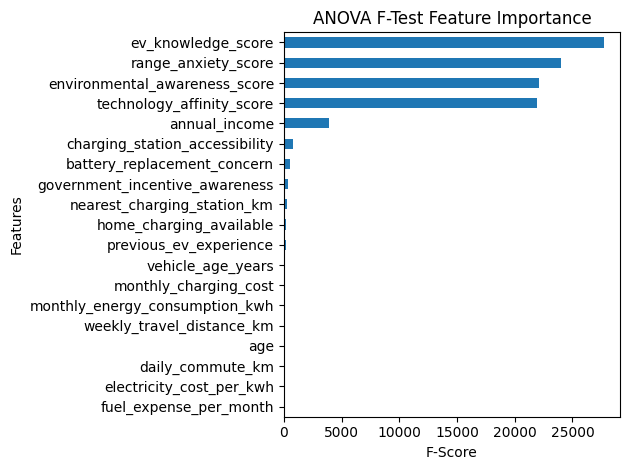

In [20]:
anovadf.sort_values("F-Score").plot(x="Feature",y="F-Score",kind="barh",legend=False)

plt.title("ANOVA F-Test Feature Importance")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [21]:
print('''The test tells us that ev_knowledge column has the highest impact on the switch
fuel expense have the least impact so we can safely drop it
''')

The test tells us that ev_knowledge column has the highest impact on the switch
fuel expense have the least impact so we can safely drop it

